In [1]:
%load_ext autoreload
%autoreload 2

# --- Standard library ---
from pathlib import Path

# --- Third-party ---
import os
import numpy as np
import pandas as pd
from pandas.api.types import is_integer_dtype
from sklearn.metrics import roc_auc_score, mean_squared_error, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from IPython.display import display, HTML

# --- Local / application ---
from rf_plateau_hpo.datasets.dataloader import load_dataset, load_datasets_yaml
from rf_plateau_hpo.core import tune_rf_oob, tune_rf_oob_plateau

%pip install -qq "dill>=0.3.8" "typing_extensions>=3.10" "matplotlib>=3.5" "seaborn>=0.11.2"
from analysis import process_dataset
from analysis import experiment_comparison_table, process_html_table, tab2tex, plot_dataset_comparisons

Note: you may need to restart the kernel to use updated packages.


In [2]:
ROOT = Path.cwd().parent
datasets_file = (ROOT / "data" / "datasets.yml").resolve()

yml = load_datasets_yaml(datasets_file)

for dataset in yml['datasets'].keys():
    X, y = load_dataset(dataset, yml=yml, base_dir=(ROOT / "data").resolve(), verbose=0)
    print(dataset, X.shape, 'reg' if not is_integer_dtype(y) else len(np.unique(y)))

iris (150, 4) 3
wine (178, 13) 3
breast_cancer (569, 30) 2
credit_card_default (30000, 23) 2
give_me_some_credit (150000, 10) 2
titanic (891, 8) 2
diabetes (442, 10) reg
abalone (4177, 8) 28
california_housing (20640, 8) reg


# Experiments

## iris

In [ ]:
dataset="iris"
X, y = load_dataset(dataset, yml=datasets_file, base_dir=(ROOT / "data").resolve())

process_dataset(
    dataset, X, y, "clf",
    score_func=lambda y, y_pred_prob: roc_auc_score(
        y, y_pred_prob, average='macro', multi_class='ovr'
    ),
    greater_is_better=True,
)

## wine

In [ ]:
dataset="wine"
X, y = load_dataset(dataset, yml=datasets_file, base_dir=(ROOT / "data").resolve())

process_dataset(
    dataset, X, y, "clf",
    score_func=lambda y, y_pred_prob: roc_auc_score(
        y, y_pred_prob, average='macro', multi_class='ovr'
    ),
    greater_is_better=True,
)

## breast_cancer

In [ ]:
dataset="breast_cancer"
X, y = load_dataset(dataset, yml=datasets_file, base_dir=(ROOT / "data").resolve())

process_dataset(
    dataset, X, y, "clf",
    score_func=lambda y, proba: roc_auc_score(y, proba[:, 1]),
    greater_is_better=True,
)

## credit_card_default

In [ ]:
dataset="credit_card_default"
X, y = load_dataset(dataset, yml=datasets_file, base_dir=(ROOT / "data").resolve())

process_dataset(
    dataset, X, y, "clf",
    score_func=lambda y, proba: roc_auc_score(y, proba[:, 1]),
    greater_is_better=True,
)

## give_me_some_credit

In [ ]:
dataset="give_me_some_credit"
X, y = load_dataset(dataset, yml=datasets_file, base_dir=(ROOT / "data").resolve())

not_nan = X.notnull().all(axis=1)
X, y = X[not_nan], y[not_nan]
weights = compute_class_weight(class_weight="balanced", classes=np.unique(y), y=y)

process_dataset(
    dataset, X, y, "clf",
    score_func = lambda y_, proba: roc_auc_score(y_, proba[:, 1]),
    greater_is_better = True,
    class_weight = {0: weights[0], 1: weights[1]},
    delta_range = [1e-3],
)

## titanic

In [ ]:
dataset="titanic"
X, y = load_dataset(dataset, yml=datasets_file, base_dir=(ROOT / "data").resolve())

X['Sex'] = (X['Sex'] == 'male').astype(int)
X['EmbarkedC'] = (X['Embarked'] == 'C').astype(int)
X['EmbarkedQ'] = (X['Embarked'] == 'Q').astype(int)
X['EmbarkedS'] = (X['Embarked'] == 'S').astype(int)
X = X.drop(['Embarked'], axis=1)

def process_cabin(v):
    if pd.isna(v) or not isinstance(v, str) or not v.strip():
        return 0, 0
    
    first_cabin = v.strip().split()[0]
    if not first_cabin[0].isalpha():
        return 0, 0
    
    level = ord(first_cabin[0].upper()) - ord('A') + 1
    cabin_number_str = first_cabin[1:].strip()
    
    if cabin_number_str and cabin_number_str.isdigit():
        cabin_num = int(cabin_number_str)
    else:
        cabin_num = 0
    
    return level, cabin_num

X['Cabin_level'], X['Cabin_num'] = zip(*[process_cabin(v) for v in X['Cabin']])
X = X.drop(['Cabin'], axis=1)
X['Age'] = X['Age'].fillna(0)

process_dataset(
    dataset, X, y, "clf",
    score_func=lambda y, y_pred: accuracy_score(y, np.argmax(y_pred, axis=1)),
    greater_is_better=True,
    max_trees=1000000,
    delta_range = [3e-3],
)

## diabetes

In [ ]:
dataset="diabetes"
X, y = load_dataset(dataset, yml=datasets_file, base_dir=(ROOT / "data").resolve())

process_dataset(
    dataset, X, y, "reg",
    score_func=lambda y, y_pred: np.sqrt(mean_squared_error(y, y_pred)),
    greater_is_better=False,
)

## abalone

In [ ]:
dataset="abalone"
X, y = load_dataset(dataset, yml=datasets_file, base_dir=(ROOT / "data").resolve())
X['M, F, and I (infant)'].replace({'M': 2, 'F': 1, 'I': 0}, inplace=True)

process_dataset(
    dataset, X, y, "reg",
    score_func=lambda y, y_pred: np.sqrt(mean_squared_error(y, y_pred)),
    greater_is_better=False,
)

## california_housing

In [ ]:
dataset="california_housing"
X, y = load_dataset(dataset, yml=datasets_file, base_dir=(ROOT / "data").resolve())

process_dataset(
    dataset, X, y, "reg",
    score_func=lambda y, y_pred: np.sqrt(mean_squared_error(y, y_pred)),
    greater_is_better=False,
    tune_criterion_range=[False],
    criterion='squared_error',
)

# Table of results

In [3]:
dataset_folders = [
    './'+dataset for dataset in yml['datasets'].keys()
    if os.path.isdir('./'+dataset)
]

delta_dir = {d: "delta=1e-3" for d in dataset_folders}
delta_dir["./titanic"] = "delta=3e-3"

dfs = []
for dataset in dataset_folders:
    dfs.append(experiment_comparison_table(
        dataset, delta_dir[dataset], 
        save_plots=True, 
        show_epsilon_column = False, 
        show_effect_size = True
    ))

cols = []

# experimemnt settings columns
for k, v in dfs[0].items():
    if k[0] =="":  
        cols.append((k, v))
        
# dataset with p_value and effect size columns
for df in dfs:
    k = df.columns[-1]
    cols.append((k, df[k]))

df_tex = pd.DataFrame(dict(cols))

df_html = df_tex.to_html(index=False, classes='dataframe')
display(HTML(process_html_table(df_html)))

## Dump subtables to latex

In [4]:
# rename in DataFrame
datasets_nl = {
    "iris,": r"iris,\\\\",
    "wine,": r"wine,\\\\",
    "breast cancer,": r"breast cancer,\\\\",
    "credit card default,": r"credit card\\\\ default,\\\\",
    "give me some credit,": r"give me\\\\ some credit,\\\\",
    "titanic,": r"titanic,\\\\",    
    "diabetes,": r"diabetes,\\\\",
    "abalone,": r"abalone,\\\\",
    "california housing,": r"california\\\\ housing,\\\\",
}
lev0 = df_tex.columns.get_level_values(level=0)
lev1 = df_tex.columns.get_level_values(level=1)
for k, v in datasets_nl.items():
    lev1 = lev1.str.replace(k, v)
df_tex.columns = pd.MultiIndex.from_arrays([lev0, lev1])

### Score: 120 $n_{trials}$ vs 40 $n_{trials}$

In [5]:
df_n_trials = df_tex.copy()
df_n_trials = df_n_trials.iloc[:8, :]
df_n_trials.iloc[:, 3] = '120 vs 40'
df_n_trials.columns = df_n_trials.columns.droplevel(0).rename('dataset')
df_n_trials = df_n_trials.set_index(df_n_trials.columns[:4].to_list())
df_n_trials = df_n_trials.stack(0).unstack([3, 2, 0, 1]).reset_index()
display(df_n_trials)

tex = tab2tex(df_n_trials)

sub = r"""\textbf{dataset} & \multicolumn{8}{c|}{\textbf{120 vs 40}} \\
 & \multicolumn{4}{c|}{\textbf{classic Optuna}} & \multicolumn{4}{c|}{\textbf{plateau search}} \\
 & \multicolumn{2}{c|}{\textbf{YES}} & \multicolumn{2}{c|}{\textbf{NO}} & \multicolumn{2}{c|}{\textbf{YES}} & \multicolumn{2}{c|}{\textbf{NO}} \\
 & \textbf{YES} & \textbf{NO} & \textbf{YES} & \textbf{NO} & \textbf{YES} & \textbf{NO} & \textbf{YES} & \textbf{NO} \\
"""

new = r"""$\mathbf{n_{trials}:}$ & \multicolumn{8}{c|}{\textbf{120 vs 40}} \\
\midrule
\textbf{algorithm:} & \multicolumn{4}{c|}{\textbf{classic Optuna}} & \multicolumn{4}{c|}{\textbf{plateau search}} \\
\midrule
\textbf{tune criterion:} & \multicolumn{2}{c|}{\textbf{YES}} & \multicolumn{2}{c|}{\textbf{NO}} & \multicolumn{2}{c|}{\textbf{YES}} & \multicolumn{2}{c|}{\textbf{NO}} \\
\midrule
\textbf{only depth:} & \textbf{YES} & \textbf{NO} & \textbf{YES} & \textbf{NO} & \textbf{YES} & \textbf{NO} & \textbf{YES} & \textbf{NO} \\
"""

# dump to latex
with open('n_trials_120_vs_40.tex', 'w') as file:
    file.write(tex.replace(sub, new))

$n_{trials}$                                    dataset  \
algorithm                                                 
tune criterion                                            
only depth                                                
0                                    iris,\\ 150x4, clf   
1                                   wine,\\ 178x13, clf   
2                          breast cancer,\\ 569x30, clf   
3                credit card\\ default,\\ 30000x23, clf   
4               give me\\ some credit,\\ 120269x10, clf   
5                                titanic,\\ 891x11, clf   
6                               diabetes,\\ 442x10, reg   
7                                abalone,\\ 4177x8, reg   
8                  california\\ housing,\\ 20640x8, reg   

$n_{trials}$                                            120 vs 40  \
algorithm                                          classic Optuna   
tune criterion                                                YES   
only depth                                                    YES   
0                  $\mathbf{2.0\times10^{-3}}$, $d=\mathbf{1.01}$   
1                                   $6.4\times10^{-1}$, $d=-0.13$   
2                              $6.4\times10^{-1}$, $\delta=-0.06$   
3               $\mathbf{3.6\times10^{-2}}$, $\delta=\mathbf{0...   
4                               $2.1\times10^{-1}$, $\delta=0.15$   
5                  $\mathbf{3.1\times10^{-3}}$, $d=\mathbf{0.96}$   
6                              $9.0\times10^{-2}$, $\delta=-0.26$   
7               $\mathbf{1.3\times10^{-2}}$, $\delta=\mathbf{-...   
8                                                                   

$n_{trials}$                                                       \
algorithm                                                           
tune criterion                                                      
only depth                                                     NO   
0               $\mathbf{4.1\times10^{-2}}$, $\delta=\mathbf{0...   
1               $\mathbf{5.7\times10^{-3}}$, $\delta=\mathbf{0...   
2                  $\mathbf{1.4\times10^{-3}}$, $d=\mathbf{1.06}$   
3                  $\mathbf{9.2\times10^{-8}}$, $d=\mathbf{2.16}$   
4               $\mathbf{9.0\times10^{-5}}$, $\delta=\mathbf{0...   
5               $\mathbf{3.0\times10^{-4}}$, $\delta=\mathbf{0...   
6                 $\mathbf{3.4\times10^{-2}}$, $d=\mathbf{-0.60}$   
7                 $\mathbf{8.5\times10^{-3}}$, $d=\mathbf{-0.84}$   
8                                                                   

$n_{trials}$                                                       \
algorithm                                                           
tune criterion                                                 NO   
only depth                                                    YES   
0                                    $2.8\times10^{-1}$, $d=0.22$   
1                          $9.4\times10^{-1}$, $d=\mathbf{-0.53}$   
2                                    $1.3\times10^{-1}$, $d=0.39$   
3                  $\mathbf{4.3\times10^{-2}}$, $d=\mathbf{0.58}$   
4               $\mathbf{2.1\times10^{-3}}$, $\delta=\mathbf{0...   
5               $\mathbf{1.0\times10^{-2}}$, $\delta=\mathbf{0...   
6                 $\mathbf{5.5\times10^{-3}}$, $d=\mathbf{-0.89}$   
7                          $7.8\times10^{-2}$, $d=\mathbf{-0.51}$   
8                                    $6.3\times10^{-1}$, $d=0.11$   

$n_{trials}$                                                       \
algorithm                                                           
tune criterion                                                      
only depth                                                     NO   
0               $\mathbf{3.2\times10^{-2}}$, $\delta=\mathbf{0...   
1                  $\mathbf{4.2\times10^{-6}}$, $d=\mathbf{1.72}$   
2                  $\mathbf{5.4\times10^{-4}}$, $d=\mathbf{1.16}$   
3                  $\mathbf{2.2\times10^{-3}}$, $d=\mat

### Score: tune criterion (YES vs NO) & only depth (YES vs NO)

In [6]:
df_tcod = df_tex.copy()
df_tcod = df_tcod.drop(df_tcod.columns[3], axis=1) # drop n_trials column
df_tcod = df_tcod.iloc[12:20, :].replace({"Score: YES vs NO": "YES vs NO"})
df_tcod.columns = df_tcod.columns.droplevel(0).rename('dataset')
df_tcod = df_tcod.set_index(df_tcod.columns[:3].to_list())
df_tcod = df_tcod.stack(0).unstack([0, 1, 2]).reset_index()
display(df_tcod)

tex = tab2tex(df_tcod, valign='m{1.7cm}')

sub = r"""\textbf{dataset} & \multicolumn{4}{c|}{\textbf{YES vs NO}} & \textbf{YES} & \textbf{NO} & \textbf{YES} & \textbf{NO} \\
 & \textbf{YES} & \textbf{NO} & \textbf{YES} & \textbf{NO} & \textbf{YES vs NO} & \textbf{YES vs NO} & \textbf{YES vs NO} & \textbf{YES vs NO} \\
 & \textbf{classic Optuna} & \textbf{classic Optuna} & \textbf{plateau search} & \textbf{plateau search} & \textbf{classic Optuna} & \textbf{classic Optuna} & \textbf{plateau search} & \textbf{plateau search} \\
"""
new = r"""\textbf{tune criterion:} & \multicolumn{4}{c|}{\textbf{YES vs NO}} & \textbf{YES} & \textbf{NO} & \textbf{YES} & \textbf{NO} \\
\midrule
\textbf{only depth:} & \textbf{YES} & \textbf{NO} & \textbf{YES} & \textbf{NO} & \multicolumn{4}{c|}{\textbf{YES vs NO}} \\
\midrule
\textbf{algorithm:} & \multicolumn{2}{c|}{\textbf{classic Optuna}} & \multicolumn{2}{c|}{\textbf{plateau search}} & \multicolumn{2}{c|}{\textbf{classic Optuna}} & \multicolumn{2}{c|}{\textbf{plateau search}} \\
"""

# dump to latex
with open('criterion_depth_yes_vs_no.tex', 'w') as file:
    file.write(tex.replace(sub, new))

tune criterion                                  dataset  \
only depth                                                
algorithm                                                 
0                                    iris,\\ 150x4, clf   
1                                   wine,\\ 178x13, clf   
2                          breast cancer,\\ 569x30, clf   
3                credit card\\ default,\\ 30000x23, clf   
4               give me\\ some credit,\\ 120269x10, clf   
5                                titanic,\\ 891x11, clf   
6                               diabetes,\\ 442x10, reg   
7                                abalone,\\ 4177x8, reg   
8                  california\\ housing,\\ 20640x8, reg   

tune criterion                                          YES vs NO  \
only depth                                                    YES   
algorithm                                          classic Optuna   
0                                    $4.5\times10^{-1}$, $d=0.25$   
1                  $\mathbf{4.2\times10^{-4}}$, $d=\mathbf{1.29}$   
2                  $\mathbf{4.8\times10^{-2}}$, $d=\mathbf{0.67}$   
3                 $\mathbf{8.4\times10^{-27}}$, $d=\mathbf{9.23}$   
4               $\mathbf{1.2\times10^{-7}}$, $\delta=\mathbf{0...   
5                      $6.2\times10^{-2}$, $\delta=\mathbf{0.34}$   
6                               $2.5\times10^{-1}$, $\delta=0.21$   
7                              $3.9\times10^{-1}$, $\delta=-0.16$   
8                                                                   

tune criterion                                                   \
only depth                                                   NO   
algorithm                                        classic Optuna   
0                            $8.5\times10^{-1}$, $\delta=-0.04$   
1                                  $4.0\times10^{-1}$, $d=0.27$   
2                $\mathbf{1.7\times10^{-3}}$, $d=\mathbf{1.13}$   
3               $\mathbf{6.3\times10^{-10}}$, $d=\mathbf{2.73}$   
4                   $9.9\times10^{-2}$, $\delta=\mathbf{-0.31}$   
5                    $1.3\times10^{-1}$, $\delta=\mathbf{0.28}$   
6                                 $2.7\times10^{-1}$, $d=-0.36$   
7                $\mathbf{4.0\times10^{-2}}$, $d=\mathbf{0.70}$   
8                                                                 

tune criterion                                                   \
only depth                                                  YES   
algorithm                                        plateau search   
0                            $4.2\times10^{-1}$, $\delta=-0.15$   
1                                  $2.0\times10^{-1}$, $d=0.42$   
2                         $1.1\times10^{-1}$, $d=\mathbf{0.53}$   
3                $\mathbf{1.7\times10^{-7}}$, $d=\mathbf{2.11}$   
4                $\mathbf{1.2\times10^{-2}}$, $d=\mathbf{0.86}$   
5                             $4.1\times10^{-1}$, $\delta=0.15$   
6                                  $5.0\times10^{-1}$, $d=0.22$   
7               $\mathbf{2.5\times10^{-2}}$, $d=\mathbf{-0.78}$   
8                                                                 

tune criterion                                                     \
only depth                                                     NO   
algorithm                                          plateau search   
0                               $7.3\times10^{-1}$, $\delta=0.06$   
1                               $9.5\times10^{-1}$, $\delta=0.01$   
2                  $\mathbf{7.0\times10^{-6}}$, $d=\mathbf{1.73}$   
3                              $9.9\times10^{-1}$, $\delta=-0.00$   
4                                    $8.3\times10^{-1}$, $d=0.07$   
5               $\mathbf{1.1\times10^{-2}}$, $\delta=\mathbf{0...   
6                                    $7.7\times10^{-1}$, $d=0.10$   
7                               $6.9\times10^{-1}$, $\delta=0.08$   
8                                                                   

tune criterion         

# Time and number of trees: Optuna vs. Plateau 

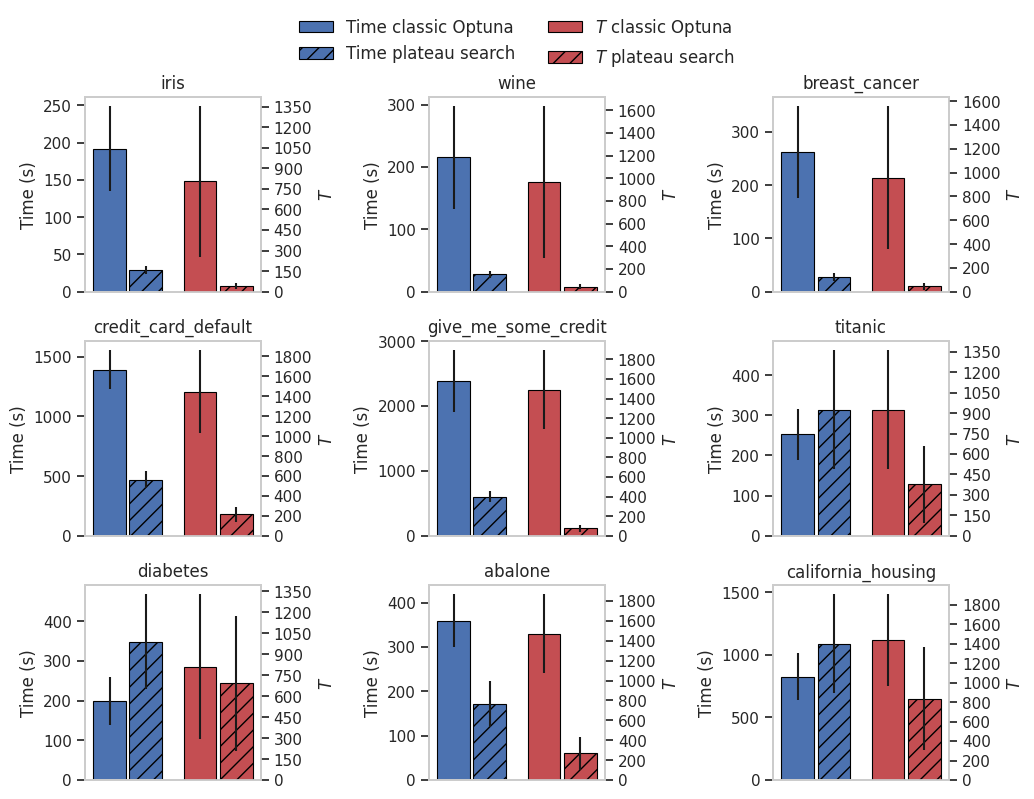

In [7]:
plot_dataset_comparisons(
    dataset_folders=dataset_folders,
    tune_criterion=False,
    depth_trees_only=False,
    delta_dir=delta_dir, 
    min_w=3.5, 
    min_h=2.3,
    tight_layout_top=0.95,
#     show_scores=True,
    ncols=3,
    save_plots=False,
)